# Si[001] `compute_SED` workflow

This notebook runs the complete local workflow for the 6 nm Si[001] example: generate the model, optionally run GPUMD, read `sed.bin`, and plot the complete reciprocal-space projection.

The current CUDA implementation bins and sums mass-weighted velocities in the $x$-$y$ plane. Therefore these plots are a projected grid spectrum with $q_z=0$, not atom-resolved, basis-preserving SED.

## 1. Setup

Run this notebook from `examples/compute_SED/si001_6nm`. The Python analysis requires NumPy and Matplotlib. GPUMD execution is disabled by default; set `RUN_GPUMD = True` only when a CUDA-enabled `gpumd` executable is available.

In [1]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

WORKDIR = Path.cwd().resolve()
if WORKDIR.name != 'si001_6nm':
    raise RuntimeError('Open Jupyter in examples/compute_SED/si001_6nm before running this notebook.')

sys.path.insert(0, str(WORKDIR.parent))
from sed_dispersion import (
    full_qx_dispersion,
    plot_full_qx_dispersion,
    plot_qspace_slices,
    projected_spectrum,
    read_sed_bin,
)

MODEL = WORKDIR / 'model.xyz'
SED_BIN = WORKDIR / 'sed.bin'
RUN_GPUMD = False
LATTICE_CONSTANT_A = 5.431

print(f'Notebook workdir: {WORKDIR}')
print(f'Model: {MODEL.name}; SED file: {SED_BIN.name}; RUN_GPUMD={RUN_GPUMD}')


Notebook workdir: /mnt/e/gpumd/c2f020de-0b0d-4f0e-a62b-4a8d5e121007/gpumd_sed/examples/compute_SED/si001_6nm
Model: model.xyz; SED file: sed.bin; RUN_GPUMD=False


## 2. Generate the 6 nm model and optionally run GPUMD

The input uses an $a/4$ grid (`dx = 1.35778` Angstrom), giving a 44 by 44 projected grid. One 4096-frame segment is about 91 MiB.

In [2]:
if not MODEL.exists():
    subprocess.run([sys.executable, 'generate_si001_model.py'], check=True)

if RUN_GPUMD:
    # Linux/WSL notebook kernel: GPUMD is three directories above this example.
    subprocess.run(['../../../src/gpumd'], check=True)

if not SED_BIN.exists():
    print('sed.bin is absent. Set RUN_GPUMD = True and rerun this cell after building GPUMD.')
else:
    print(f'Using {SED_BIN} ({SED_BIN.stat().st_size / 2**20:.1f} MiB)')


Using /mnt/e/gpumd/c2f020de-0b0d-4f0e-a62b-4a8d5e121007/gpumd_sed/examples/compute_SED/si001_6nm/sed.bin (90.8 MiB)


## 3. Read `sed.bin` and inspect the sampling metadata

In [3]:
if not SED_BIN.exists():
    raise FileNotFoundError('Generate sed.bin in the previous cell before continuing.')

header, data = read_sed_bin(SED_BIN)
for key in ('sed_length', 'num_segments', 'nx', 'ny', 'sample_interval', 'dt_sample_ps', 'nyquist_frequency', 'dx'):
    print(f'{key:>18s}: {header[key]}')
print('data shape [segment, time, component, y, x]:', data.shape)


        sed_length: 4096
      num_segments: 1
                nx: 44
                ny: 44
   sample_interval: 5
      dt_sample_ps: 0.004999999888241291
 nyquist_frequency: 100.0
                dx: 1.3577799797058105
data shape [segment, time, component, y, x]: (1, 4096, 3, 44, 44)


## 4. Compute the complete reciprocal-space spectrum

The spatial axes are FFT-shifted. For this $a/4$ grid, the closed interval is approximately $[-G,G]$, where $G=4\pi/a$; the high-symmetry sequence along $q_x$ is $\Gamma-X-\Gamma-X-\Gamma$.

In [4]:
frequency_thz, qx, qy, power = projected_spectrum(data, header)
qx_closed, qx_intensity = full_qx_dispersion(frequency_thz, qx, qy, power)

x_point = 2 * np.pi / LATTICE_CONSTANT_A
g_point = 2 * x_point
print(f'delta q = {qx[1] - qx[0]:.6f} rad/A')
print(f'closed qx range = [{qx_closed[0]:.6f}, {qx_closed[-1]:.6f}] rad/A')
print(f'X = {x_point:.6f} rad/A, G = {g_point:.6f} rad/A')
print('power shape [frequency, qy, qx]:', power.shape)


delta q = 0.105171 rad/A
closed qx range = [-2.313772, 2.313772] rad/A
X = 1.156911 rad/A, G = 2.313823 rad/A
power shape [frequency, qy, qx]: (2049, 44, 44)


## 5. Plot the full extended-zone dispersion

This is the $q_y=q_z=0$ line through the complete projected FFT cell.

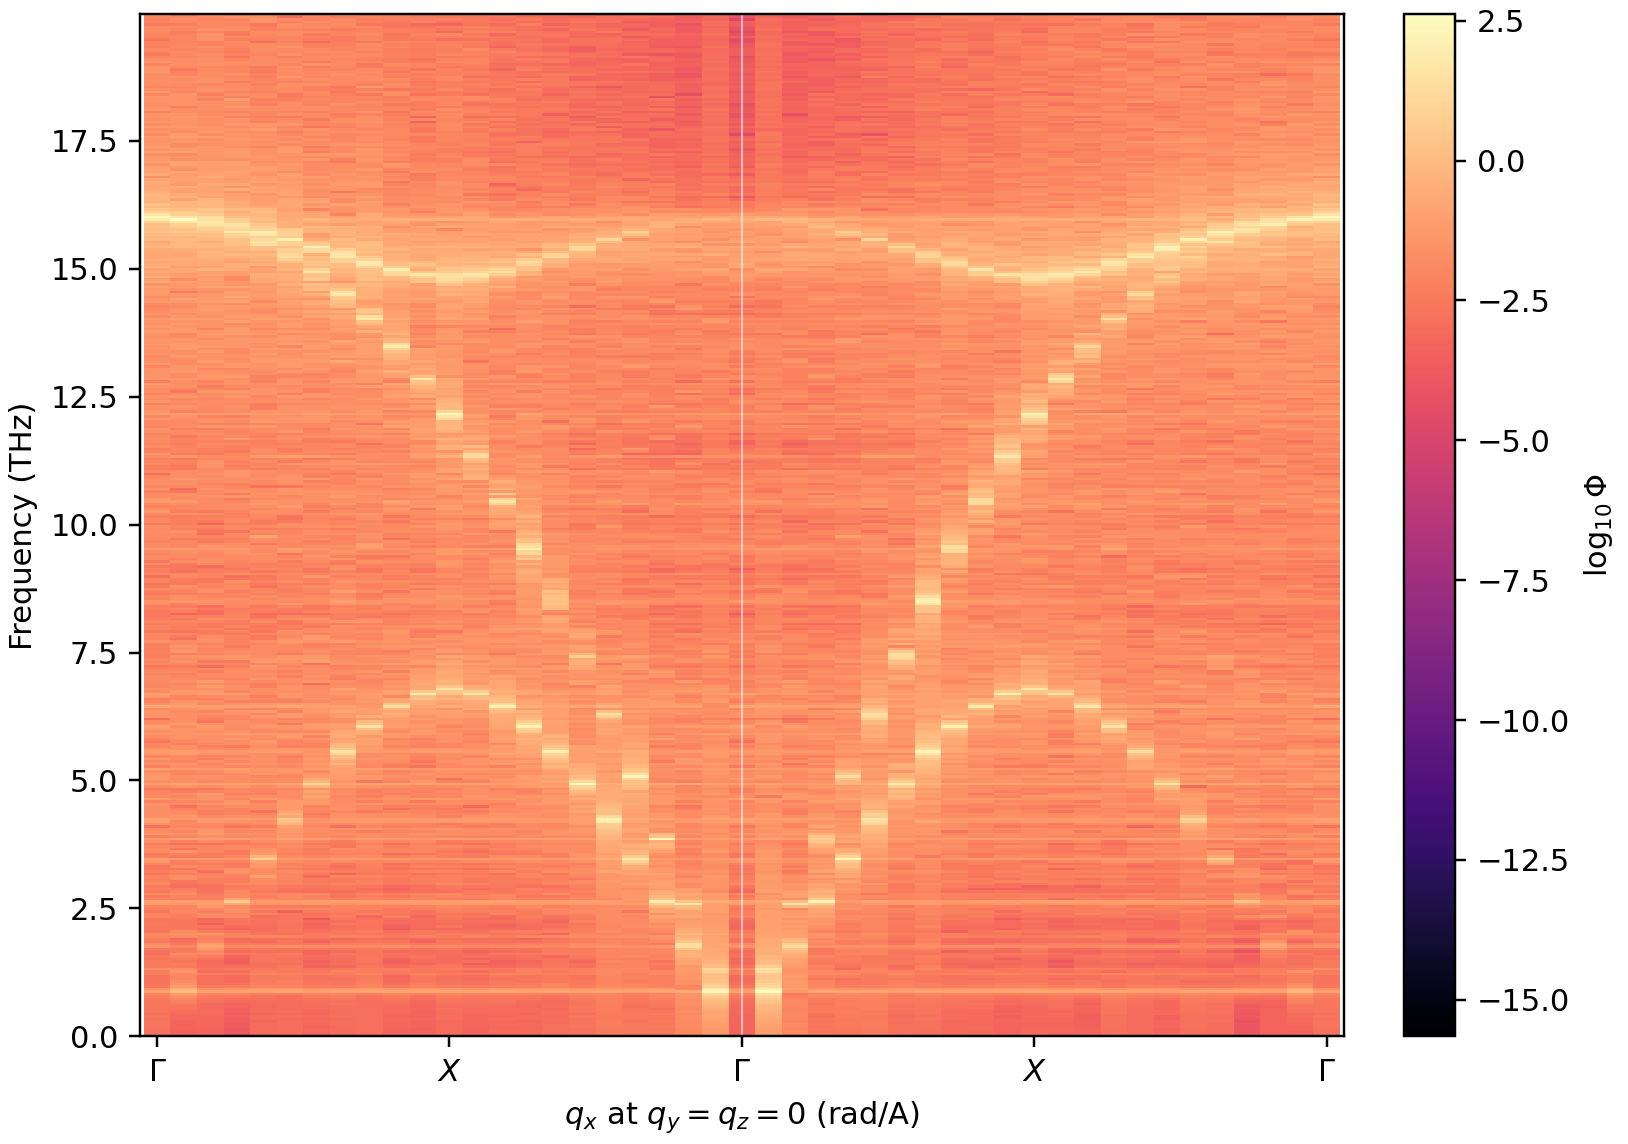

In [5]:
DISPERSION_PNG = WORKDIR / 'full_qx_dispersion_20THz.png'
plot_full_qx_dispersion(
    frequency_thz, qx_closed, qx_intensity, DISPERSION_PNG,
    fmax=20.0, lattice_constant=LATTICE_CONSTANT_A,
)
display(Image(filename=str(DISPERSION_PNG)))


## 6. Plot full $q_x$-$q_y$ energy slices

Requested frequencies are matched to the nearest discrete frequency bin. Change `SLICE_FREQUENCIES_THz` to inspect other energies.

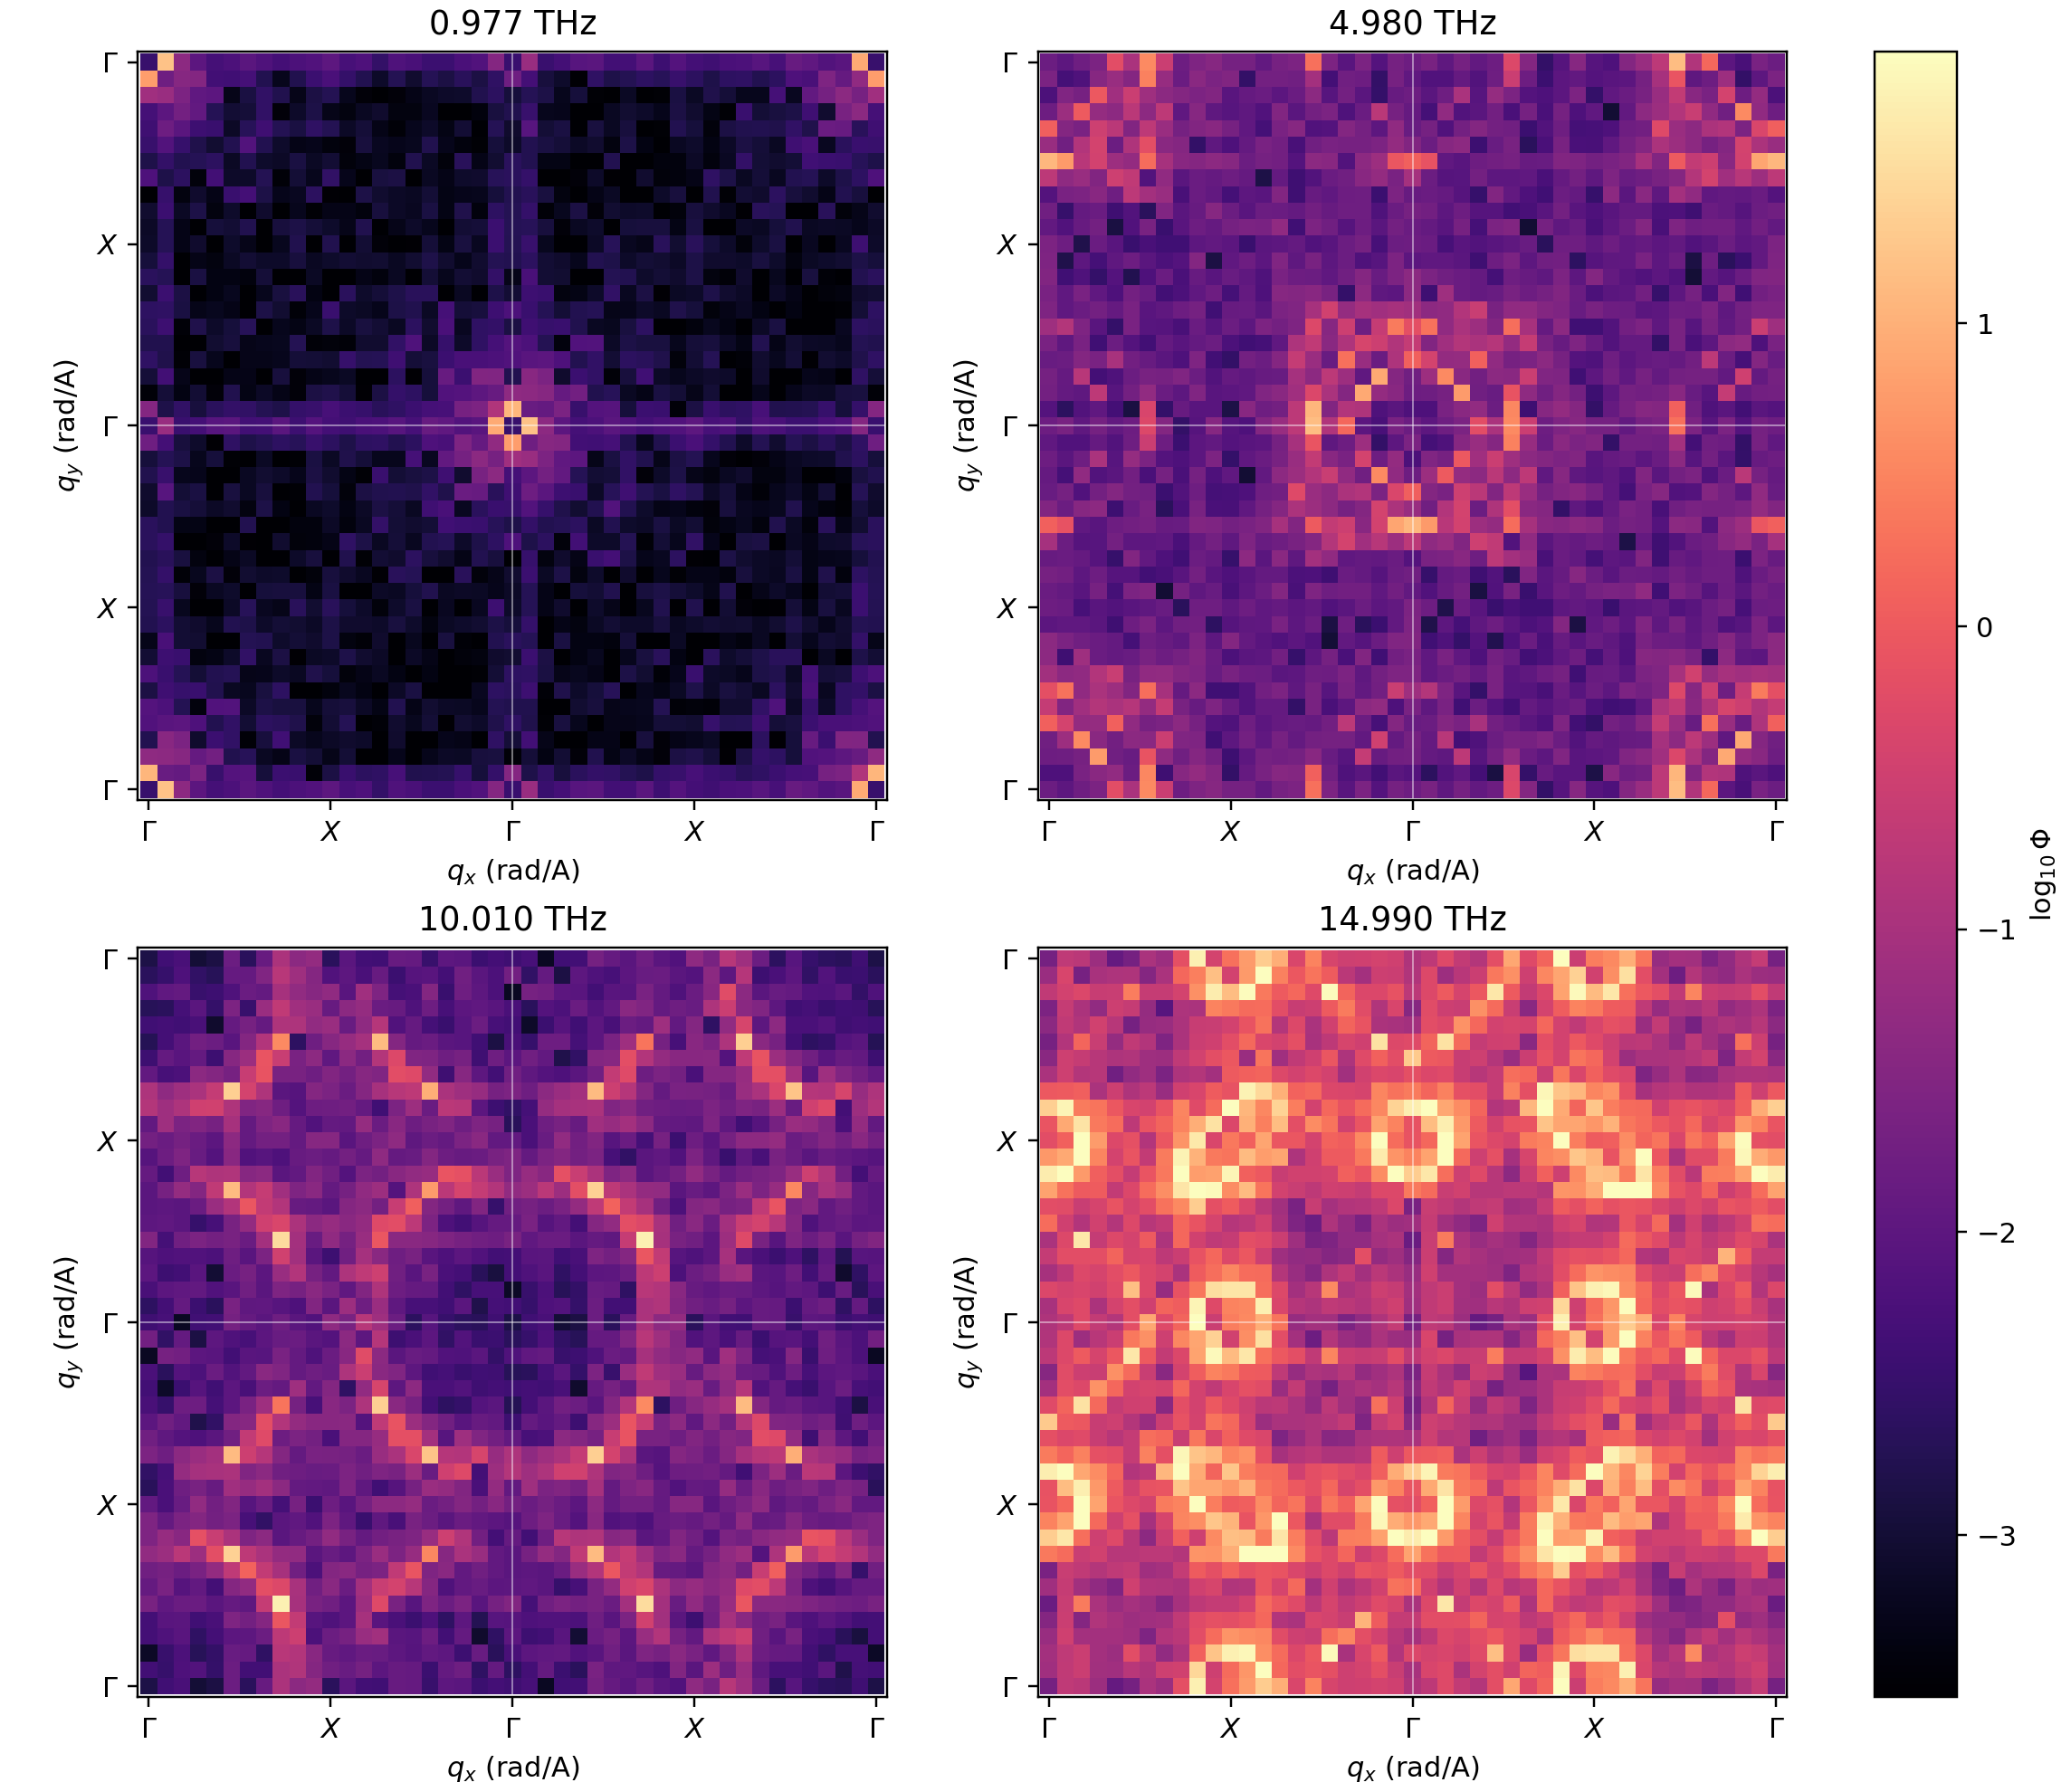

In [6]:
SLICE_FREQUENCIES_THz = (1.0, 5.0, 10.0, 15.0)
SLICES_PNG = WORKDIR / 'full_q_slices.png'
plot_qspace_slices(
    frequency_thz, qx, qy, power, SLICE_FREQUENCIES_THz, SLICES_PNG,
    lattice_constant=LATTICE_CONSTANT_A,
)
display(Image(filename=str(SLICES_PNG)))


## 7. Extract one numerical slice

This cell exposes the raw intensity map for custom analysis instead of only saving a figure.

Using frequency bin 205: 10.009766 THz
intensity map shape [qy, qx]: (44, 44)


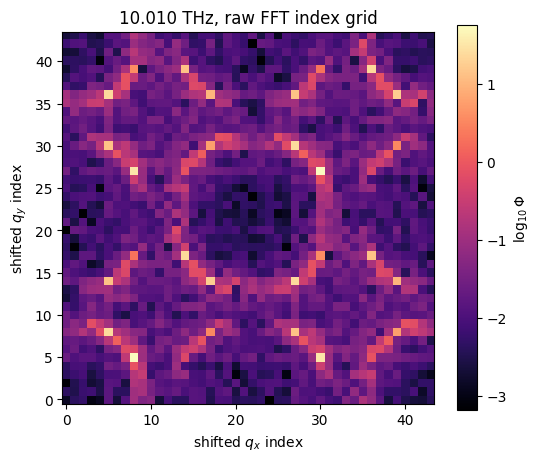

In [7]:
target_frequency_thz = 10.0
index = int(np.argmin(np.abs(frequency_thz - target_frequency_thz)))
selected_frequency_thz = frequency_thz[index]
intensity_qy_qx = power[index]

print(f'Using frequency bin {index}: {selected_frequency_thz:.6f} THz')
print('intensity map shape [qy, qx]:', intensity_qy_qx.shape)

plt.figure(figsize=(6, 5))
plt.imshow(np.log10(intensity_qy_qx + np.finfo(float).eps), origin='lower', aspect='equal', cmap='magma')
plt.colorbar(label=r'$\log_{10}\Phi$')
plt.title(f'{selected_frequency_thz:.3f} THz, raw FFT index grid')
plt.xlabel('shifted $q_x$ index')
plt.ylabel('shifted $q_y$ index')
plt.show()
